# Oracle alpha against historical charge-off rates

This notebook checks when the foresight/oracle allocation behaves well in the decision problem.
It uses the realised quarterly charge-off rate as the historical outcome, plots it against
`alpha_oracle`, and audits that the PTO and black-box result files contain identical
ground-truth decision variables before making comparisons.

The oracle calculation reproduces the v2 notebooks: simple x4 charge-off inversion,
Basel IRB with a 0.03% annual-PD floor, and the shared 101-point alpha grid.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

MINOU_COLORS = {
    'teal': '#00798C', 'coral': '#D1495B', 'gold': '#EDAE49',
    'sage': '#66A182', 'navy': '#2E4057', 'grey': '#8D96A3',
}

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'models' / 'notebooks' / 'results').exists():
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / 'models' / 'notebooks' / 'results'
FIGURES_DIR = ROOT / 'decision_problem' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_SETTING = 'modern'  # saved v2 output used for the overlap audit
suffix = '' if DATA_SETTING == 'base' else f'_{DATA_SETTING}'
PTO_PATH = RESULTS_DIR / f'pto_quarterly_pd_irb_predictions{suffix}.csv'
BLACKBOX_PATH = RESULTS_DIR / f'blackbox_quarterly_pd_irb_predictions{suffix}.csv'
if not PTO_PATH.exists() or not BLACKBOX_PATH.exists():
    raise FileNotFoundError(f'Missing matched files for DATA_SETTING={DATA_SETTING}: {PTO_PATH}, {BLACKBOX_PATH}')

pto = pd.read_csv(PTO_PATH, parse_dates=['date']).set_index('date').sort_index()
blackbox = pd.read_csv(BLACKBOX_PATH, parse_dates=['date']).set_index('date').sort_index()
chargeoff_path = ROOT / 'data' / 'processed' / 'fred_loan_return_aligned.csv'
history = pd.read_csv(chargeoff_path, parse_dates=['DATE']).set_index('DATE').sort_index()
print(f'Setting: {DATA_SETTING}; PTO rows: {len(pto)}; black-box rows: {len(blackbox)}; full history rows: {len(history)}')

Setting: modern; PTO rows: 36; black-box rows: 36; full history rows: 169


In [81]:
# Cross-file audit: these are not model predictions; they define the shared decision environment.
GROUND_TRUTH = ['c_annual_raw', 'c_q_lag1', 'c_q_realised', 'pd_q_realised', 'pd_a_realised',
                'k_irb_realised', 'alpha_oracle', 'utility_oracle']
shared_dates = pto.index.intersection(blackbox.index)
audit = []
for col in GROUND_TRUTH:
    if col not in pto or col not in blackbox:
        audit.append({'column': col, 'max_abs_diff': np.nan, 'status': 'missing'})
        continue
    diff = np.abs(pto.loc[shared_dates, col] - blackbox.loc[shared_dates, col])
    audit.append({'column': col, 'max_abs_diff': diff.max(), 'status': 'ok' if diff.max() <= 1e-10 else 'DIFF'})
audit = pd.DataFrame(audit).set_index('column')
display(audit)
assert (audit['status'] == 'ok').all(), 'PTO and black-box ground truths are not identical.'

# Use PTO as the canonical ground-truth frame after the audit.
# Reproduce the v2 oracle exactly for every historical quarter.
LGD, LEVERAGE, Y_BAR, LAMBDA, PD_FLOOR = 0.45, 10.0, 0.0168, 10.0, 3e-4
ALPHA_GRID = np.linspace(0.0, 1.0, 101)
def quarterly_pd_to_annual(pd_q):
    pd_q = np.clip(np.asarray(pd_q, dtype=float), 1e-6, 0.99)
    return np.clip(1.0 - (1.0 - pd_q) ** 4, 1e-6, 0.99)
def k_irb_from_annual_pd(pd_a):
    from scipy.stats import norm
    pd_a = np.maximum(np.clip(np.asarray(pd_a, dtype=float), 1e-6, 0.99), PD_FLOOR)
    r = 0.12 * (1 - np.exp(-50 * pd_a)) / (1 - np.exp(-50)) + 0.24 * (1 - (1 - np.exp(-50 * pd_a)) / (1 - np.exp(-50)))
    b = (0.11852 - 0.05478 * np.log(pd_a)) ** 2
    z = norm.ppf(pd_a) / np.sqrt(1 - r) + np.sqrt(r / (1 - r)) * norm.ppf(0.999)
    return np.maximum(0.45 * (norm.cdf(z) - pd_a) / (1 - 1.5 * b) * (1 + (2.5 - 2.5) * b), 0.0)
def oracle_from_chargeoff(c_q):
    pd_q = np.clip(c_q / LGD, 1e-6, 0.99)
    pd_a = quarterly_pd_to_annual(pd_q)
    k = k_irb_from_annual_pd(pd_a)
    exposure = LEVERAGE * ALPHA_GRID
    terminal = 1.0 + exposure * (Y_BAR - c_q)
    available = terminal - ALPHA_GRID
    shortfall = np.maximum(k * exposure - available, 0.0)
    utility = terminal - LAMBDA * shortfall
    i = int(np.argmax(utility))
    return float(ALPHA_GRID[i]), float(utility[i])

history['c_q'] = history['charge_off_rate'] / 100.0 / 4.0
history = history.dropna(subset=['c_q']).copy()
history[['alpha_oracle_computed', 'utility_oracle_computed']] = history['c_q'].apply(lambda c: pd.Series(oracle_from_chargeoff(c)))
df = history[['c_q', 'alpha_oracle_computed', 'utility_oracle_computed']].copy()
df['chargeoff_quantile'] = df['c_q'].rank(pct=True)
overlap = df.index.intersection(shared_dates)
saved_alpha_diff = np.abs(df.loc[overlap, 'alpha_oracle_computed'] - pto.loc[overlap, 'alpha_oracle'])
saved_utility_diff = np.abs(df.loc[overlap, 'utility_oracle_computed'] - pto.loc[overlap, 'utility_oracle'])
print(f'Computed-vs-saved v2 oracle max alpha difference: {saved_alpha_diff.max():.3g}')
print(f'Computed-vs-saved v2 oracle max utility difference: {saved_utility_diff.max():.3g}')
assert saved_alpha_diff.max() <= 1e-12 and saved_utility_diff.max() <= 1e-12
df.describe().T.round(6)

,max_abs_diff,status
column,,
c_annual_raw,0.0,ok
c_q_lag1,0.0,ok
c_q_realised,0.0,ok
pd_q_realised,0.0,ok
pd_a_realised,0.0,ok
k_irb_realised,0.0,ok
alpha_oracle,0.0,ok
utility_oracle,0.0,ok


Computed-vs-saved v2 oracle max alpha difference: 0
Computed-vs-saved v2 oracle max utility difference: 2.22e-16


,count,mean,std,min,25%,50%,75%,max
c_q,165.0,0.001889,0.001433,0.000300,0.000775,0.001375,0.003000,0.006425
alpha_oracle_computed,165.0,0.611576,0.080562,0.460000,0.530000,0.610000,0.670000,0.800000
utility_oracle_computed,165.0,1.092239,0.019922,1.047725,1.073140,1.094092,1.107368,1.132000
chargeoff_quantile,165.0,0.503030,0.289500,0.012121,0.272727,0.509091,0.754545,1.000000


## Oracle behaviour over time

The full sample is shown in one plot. The alpha axis is deliberately zoomed
to 0.5–0.8 so the allocation swings are visible.

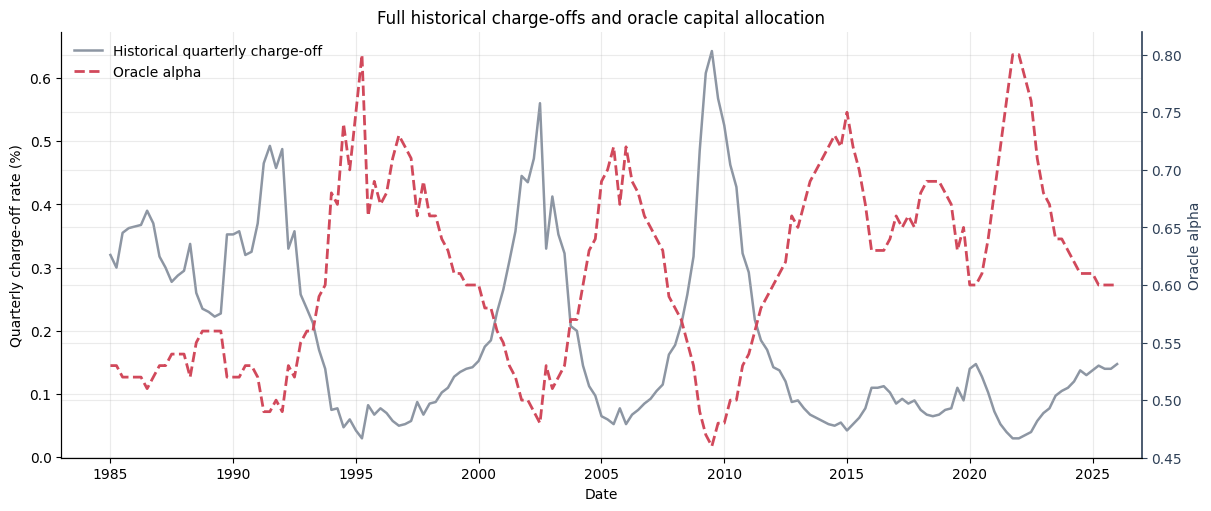

In [83]:
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25})
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax2 = ax.twinx()
ax.plot(df.index, df['c_q'] * 100, color=MINOU_COLORS['grey'], lw=1.8, label='Historical quarterly charge-off')
ax2.plot(df.index, df['alpha_oracle_computed'], color=MINOU_COLORS['coral'], lw=2.0, ls='--', label='Oracle alpha')
ax.set_ylabel('Quarterly charge-off rate (%)'); ax2.set_ylabel('Oracle alpha'); ax2.set_ylim(0.45, 0.82)
ax2.set_yticks(np.arange(0.45, 0.821, 0.05)); ax2.yaxis.set_major_formatter(__import__('matplotlib').ticker.FormatStrFormatter('%.2f'))
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color(MINOU_COLORS['navy']); ax2.spines['right'].set_linewidth(1.2)
ax2.tick_params(axis='y', colors=MINOU_COLORS['navy']); ax2.yaxis.label.set_color(MINOU_COLORS['navy'])
ax.set_title('Full historical charge-offs and oracle capital allocation')
ax.set_xlabel('Date'); ax.set_xlim(pd.Timestamp('1983-01-01'), pd.Timestamp('2027-01-01')); ax.xaxis.set_major_locator(mdates.YearLocator(5)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
lines = ax.get_lines() + ax2.get_lines(); ax.legend(lines, [line.get_label() for line in lines], frameon=False, loc='upper left')
fig.savefig(FIGURES_DIR / f'historical_oracle_against_chargeoffs.png', dpi=200, bbox_inches='tight')
plt.show()

## Basel asset correlation and IRB capital requirement

This reproduces the regulatory curves from `IRB_capital_constraint.ipynb`, using
the v2 convention that `K_IRB` receives annualised PD. The two curves share the
same annualised-PD x-axis and use separate y-axes because they have different scales.

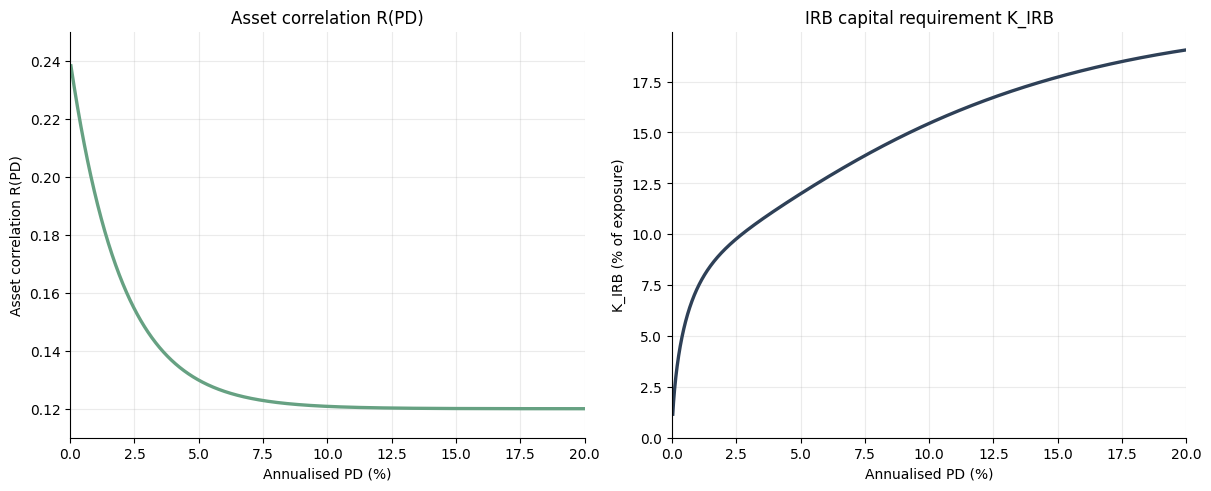

In [84]:
pd_annual_grid = np.linspace(PD_FLOOR, 0.20, 2000)
r_grid = 0.12 * (1 - np.exp(-50 * pd_annual_grid)) / (1 - np.exp(-50)) + 0.24 * (1 - (1 - np.exp(-50 * pd_annual_grid)) / (1 - np.exp(-50)))
k_grid = k_irb_from_annual_pd(pd_annual_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].plot(pd_annual_grid * 100, r_grid, color=MINOU_COLORS['sage'], lw=2.4)
axes[0].set_xlabel('Annualised PD (%)'); axes[0].set_ylabel('Asset correlation R(PD)')
axes[0].set_title('Asset correlation R(PD)'); axes[0].set_xlim(0, 20); axes[0].set_ylim(0.11, 0.25)
axes[0].grid(True, alpha=0.25)
axes[1].plot(pd_annual_grid * 100, k_grid * 100, color=MINOU_COLORS['navy'], lw=2.4)
axes[1].set_xlabel('Annualised PD (%)'); axes[1].set_ylabel('K_IRB (% of exposure)')
axes[1].set_title('IRB capital requirement K_IRB'); axes[1].set_xlim(0, 20); axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.25)
fig.savefig(FIGURES_DIR / 'asset_correlation_and_irb_capital.png', dpi=220, bbox_inches='tight')
plt.show()

## Charge-off regimes and oracle allocation

This reproduces the regime diagnostics from `charge_offs_data.ipynb`.
The post-recession extension is configurable as a fraction of each recession's duration.
The time series and regime distributions are stacked into one thesis-oriented figure.

## When does oracle alpha behave well?

Here “well” means that alpha responds to the historical charge-off environment in the
intended direction: alpha is lower when charge-offs are high, and it is stable when
charge-offs are close to their lagged value. The binned summaries are descriptive,
not causal tests.

,Normal regime,Stress regime
Parameter,,
"μ (mean charge-off rate, %)",0.14%,0.36%
"σ (standard deviation, %)",0.10%,0.15%
Implied quarterly PD = μ / LGD (%),0.31%,0.79%
Implied annualised PD (%),1.24%,3.13%
"K_IRB (Basel capital requirement, %)",7.96%,10.40%


,Value
Parameter,
LGD,0.45
M (maturity),2.5
K1 (initial capital),1.0
Leverage,10.0
y_bar,0.0168
Lambda penalty,10.0
PD floor,0.0003
Alpha grid,101 points from 0 to 1


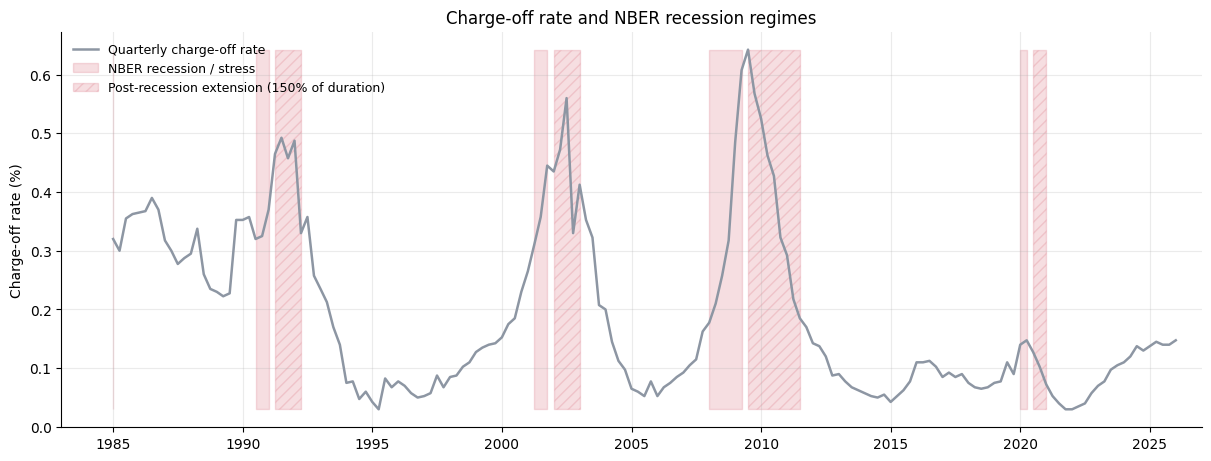

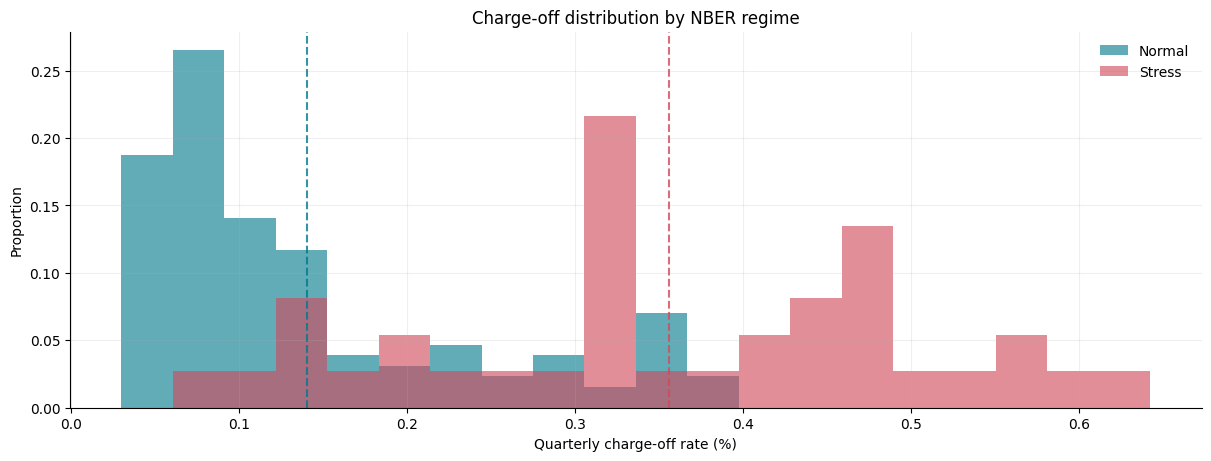

In [75]:
USREC_PATH = ROOT / 'data' / 'raw' / 'fred_loan_return' / 'USREC.csv'
REGIME_EXTENSION_FRACTION = 1.50
usrec = pd.read_csv(USREC_PATH).rename(columns={'observation_date': 'DATE'})
usrec['DATE'] = pd.to_datetime(usrec['DATE'])
usrec['USREC'] = pd.to_numeric(usrec['USREC'].replace('.', np.nan), errors='coerce')
usrec = usrec.dropna(subset=['DATE', 'USREC']).set_index('DATE').sort_index()
usrec_quarterly = usrec['USREC'].astype(int).resample('QS').max().astype(bool)
recession_starts = usrec_quarterly[usrec_quarterly & ~usrec_quarterly.shift(1, fill_value=False)].index
recession_ends = usrec_quarterly[usrec_quarterly & ~usrec_quarterly.shift(-1, fill_value=False)].index
# The raw FRED series is annualised. Use the same quarterly charge-off rate
# that feeds the v2 decision problem, displayed as a percentage below.
regimes = history[['c_q']].rename(columns={'c_q': 'charge_off_rate'}).copy()
regimes['nber_recession'] = usrec_quarterly.reindex(regimes.index, method='ffill').fillna(False).astype(bool)
regimes['nber_recession_extended'] = regimes['nber_recession'].copy()
for start, end in zip(recession_starts, recession_ends):
    duration_q = max(1, (end.year - start.year) * 4 + end.quarter - start.quarter + 1)
    extension_q = int(np.ceil(duration_q * REGIME_EXTENSION_FRACTION))
    extension_end = end + pd.DateOffset(months=3 * extension_q)
    extension_mask = (regimes.index > end) & (regimes.index <= extension_end)
    regimes.loc[extension_mask, 'nber_recession_extended'] = True
regimes['extension_only'] = regimes['nber_recession_extended'] & ~regimes['nber_recession']
regimes['regime'] = np.where(regimes['nber_recession_extended'], 'stress', 'normal')
regime_params = regimes.groupby('regime')['charge_off_rate'].agg(mu='mean', sigma='std', observations='count').reindex(['normal', 'stress'])
regime_table = regime_params.copy()
regime_table['pd_q_mu'] = regime_table['mu'] / LGD
regime_table['pd_a_mu'] = quarterly_pd_to_annual(regime_table['pd_q_mu'].to_numpy())
regime_table['k_irb_pd_a_mu'] = k_irb_from_annual_pd(regime_table['pd_a_mu'].to_numpy())
regime_table['pd_a_mu_minus_1sd'] = quarterly_pd_to_annual(np.maximum((regime_table['mu'] - regime_table['sigma']) / LGD, 1e-6).to_numpy())
regime_table['pd_a_mu_plus_1sd'] = quarterly_pd_to_annual(((regime_table['mu'] + regime_table['sigma']) / LGD).to_numpy())
regime_table['k_irb_mu_minus_1sd'] = k_irb_from_annual_pd(regime_table['pd_a_mu_minus_1sd'].to_numpy())
regime_table['k_irb_mu_plus_1sd'] = k_irb_from_annual_pd(regime_table['pd_a_mu_plus_1sd'].to_numpy())
clean_table = pd.DataFrame({
    'Parameter': ['μ (mean charge-off rate, %)', 'σ (standard deviation, %)', 'Implied quarterly PD = μ / LGD (%)', 'Implied annualised PD (%)', 'K_IRB (Basel capital requirement, %)'],
    'Normal regime': [regime_params.loc['normal', 'mu'] * 100, regime_params.loc['normal', 'sigma'] * 100, regime_table.loc['normal', 'pd_q_mu'] * 100, regime_table.loc['normal', 'pd_a_mu'] * 100, regime_table.loc['normal', 'k_irb_pd_a_mu'] * 100],
    'Stress regime': [regime_params.loc['stress', 'mu'] * 100, regime_params.loc['stress', 'sigma'] * 100, regime_table.loc['stress', 'pd_q_mu'] * 100, regime_table.loc['stress', 'pd_a_mu'] * 100, regime_table.loc['stress', 'k_irb_pd_a_mu'] * 100],
}).set_index('Parameter')
display(clean_table.style.format('{:.2f}%'))
capital_config = pd.DataFrame({
    'Parameter': ['LGD', 'M (maturity)', 'K1 (initial capital)', 'Leverage', 'y_bar', 'Lambda penalty', 'PD floor', 'Alpha grid'],
    'Value': [LGD, 2.5, 1.0, LEVERAGE, Y_BAR, LAMBDA, PD_FLOOR, '101 points from 0 to 1'],
}).set_index('Parameter')
display(capital_config)
chargeoff_pct = regimes['charge_off_rate'] * 100.0

# Colours from the supplied paper palette: distinct teal/blue regimes and a
# contrasting green extension shade.
COLOUR_LINE, COLOUR_NORMAL, COLOUR_STRESS = MINOU_COLORS['grey'], MINOU_COLORS['teal'], MINOU_COLORS['coral']
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
ax.plot(regimes.index, chargeoff_pct, color=COLOUR_LINE, lw=1.8, label='Quarterly charge-off rate')
ymin, ymax = chargeoff_pct.min(), chargeoff_pct.max()
ax.fill_between(regimes.index, ymin, ymax, where=regimes['nber_recession'].to_numpy(), color=COLOUR_STRESS, alpha=0.18, step='mid', label='NBER recession / stress')
ax.fill_between(regimes.index, ymin, ymax, where=regimes['extension_only'].to_numpy(), color=COLOUR_STRESS, alpha=0.18, step='mid', hatch='///', label=f'Post-recession extension ({REGIME_EXTENSION_FRACTION:.0%} of duration)')
ax.set_ylabel('Charge-off rate (%)'); ax.set_title('Charge-off rate and NBER recession regimes')
ax.legend(frameon=False, loc='upper left', fontsize=9); ax.grid(True, alpha=0.25)
ax.set_xlim(pd.Timestamp('1983-01-01'), pd.Timestamp('2027-01-01'))
ax.xaxis.set_major_locator(mdates.YearLocator(5)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.savefig(FIGURES_DIR / f'chargeoff_nber_regimes.png', dpi=220, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
normal = chargeoff_pct.loc[regimes['regime'].eq('normal')]
stress = chargeoff_pct.loc[regimes['regime'].eq('stress')]
bins = np.linspace(chargeoff_pct.min(), chargeoff_pct.max(), 21)
ax.hist(normal, bins=bins, weights=np.ones(len(normal)) / len(normal), alpha=0.62, color=COLOUR_NORMAL, label='Normal')
ax.hist(stress, bins=bins, weights=np.ones(len(stress)) / len(stress), alpha=0.62, color=COLOUR_STRESS, label='Stress')
ax.axvline(regime_params.loc['normal', 'mu'] * 100, color=COLOUR_NORMAL, ls='--', lw=1.5, alpha=0.8)
ax.axvline(regime_params.loc['stress', 'mu'] * 100, color=COLOUR_STRESS, ls='--', lw=1.5, alpha=0.8)
ax.set_xlabel('Quarterly charge-off rate (%)'); ax.set_ylabel('Proportion'); ax.set_title('Charge-off distribution by NBER regime')
ax.legend(frameon=False, loc='upper right'); ax.grid(True, alpha=0.2)
fig.savefig(FIGURES_DIR / f'chargeoff_regime_distribution.png', dpi=220, bbox_inches='tight')
plt.show()

## Forecast error versus decision regret

This is a clearer version of the final diagnostic figure from
`pd_irb_vasicek_allocation_exploration.ipynb`: ordinary squared quarterly-PD
forecast error is compared with downstream decision regret.

In [76]:
true_pd_levels = [0.001, 0.003, 0.005, 0.010]
forecast_multipliers = np.linspace(0.25, 3.0, 220)

def decision_utility_for_pd(alpha, pd_q_true):
    c_q = LGD * pd_q_true; pd_a = quarterly_pd_to_annual(pd_q_true)
    k = float(k_irb_from_annual_pd(pd_a)); exposure = LEVERAGE * alpha
    terminal = 1.0 + exposure * (Y_BAR - c_q); available = terminal - alpha
    shortfall = max(k * exposure - available, 0.0)
    return terminal - LAMBDA * shortfall

from scipy.optimize import minimize_scalar
def smooth_alpha_from_pd(pd_q):
    result = minimize_scalar(lambda a: -decision_utility_for_pd(float(a), pd_q), bounds=(0.0, 1.0), method='bounded', options={'xatol': 1e-10})
    candidates = [(float(result.x), -float(result.fun)), (0.0, decision_utility_for_pd(0.0, pd_q)), (1.0, decision_utility_for_pd(1.0, pd_q))]
    return max(candidates, key=lambda item: item[1])[0]

plot_pds = true_pd_levels
forecast_diagnostic_rows = []
for pd_true_value in plot_pds:
    for multiplier in forecast_multipliers:
        pd_hat_value = np.clip(pd_true_value * multiplier, 1e-6, 0.99)
        alpha_hat_value = smooth_alpha_from_pd(pd_hat_value)
        alpha_oracle_value = smooth_alpha_from_pd(pd_true_value)
        utility_oracle_value = decision_utility_for_pd(alpha_oracle_value, pd_true_value)
        utility_hat_value = decision_utility_for_pd(alpha_hat_value, pd_true_value)
        forecast_diagnostic_rows.append({'pd_true_quarterly': pd_true_value, 'forecast_multiplier': multiplier, 'forecast_error': pd_hat_value - pd_true_value, 'alpha_oracle': alpha_oracle_value, 'alpha_hat': alpha_hat_value, 'regret': max(utility_oracle_value - utility_hat_value, 0.0)})
forecast_diagnostics_df = pd.DataFrame(forecast_diagnostic_rows)

In [77]:
bins = pd.qcut(df['c_q'], q=5, duplicates='drop')
summary = df.groupby(bins, observed=True).agg(mean_chargeoff=('c_q','mean'), mean_alpha=('alpha_oracle_computed','mean'), median_alpha=('alpha_oracle_computed','median'), mean_utility=('utility_oracle_computed','mean'), n=('alpha_oracle_computed','size'))
display(summary.round(6))
print('Spearman alpha vs charge-off:', df['alpha_oracle_computed'].corr(df['c_q'], method='spearman'))

,mean_chargeoff,mean_alpha,median_alpha,mean_utility,n
c_q,,,,,
"(-0.0007000000000000001, 0.000675]",0.000535,0.723529,0.72,1.117722,34
"(0.000675, 0.00104]",0.000843,0.661875,0.66,1.105628,32
"(0.00104, 0.0017]",0.001323,0.611765,0.61,1.094710,34
"(0.0017, 0.00323]",0.002554,0.551250,0.55,1.078614,32
"(0.00323, 0.00642]",0.004236,0.505758,0.51,1.063665,33


Spearman alpha vs charge-off: -0.9990428457898349


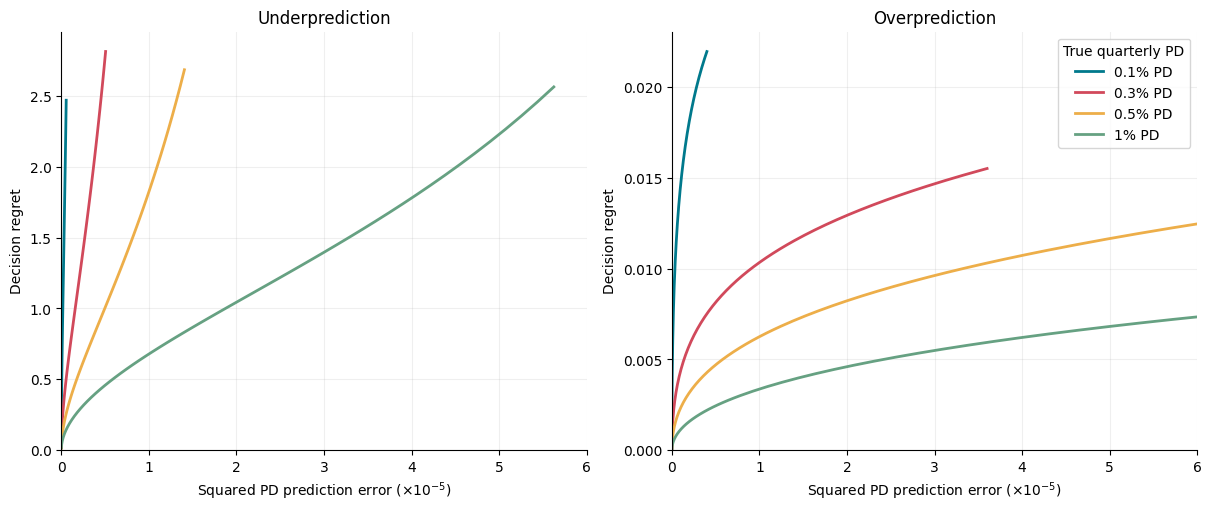

In [85]:
df = forecast_diagnostics_df.copy()
df["squared_prediction_error"] = df["forecast_error"] ** 2
df["squared_prediction_error_scaled"] = (
    1e5 * df["squared_prediction_error"]
)

under_df = df[df["forecast_multiplier"] < 1].copy()
over_df = df[df["forecast_multiplier"] > 1].copy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=False,
    constrained_layout=True
)

for panel_df, title, ax in [
    (under_df, "Underprediction", axes[0]),
    (over_df, "Overprediction", axes[1]),
]:
    for pd_true_value, curve_color in zip(plot_pds, [MINOU_COLORS['teal'], MINOU_COLORS['coral'], MINOU_COLORS['gold'], MINOU_COLORS['sage']]):
        subset = (
            panel_df[
                panel_df["pd_true_quarterly"] == pd_true_value
            ]
            .sort_values("squared_prediction_error_scaled")
        )

        ax.plot(
            subset["squared_prediction_error_scaled"],
            subset["regret"],
            lw=2,
            color=curve_color,
            label=f"{100 * pd_true_value:.2g}% PD",
        )

    ax.set_title(title)
    ax.set_xlabel(
        r"Squared PD prediction error ($\times 10^{-5}$)"
    )
    ax.set_ylabel("Decision regret")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)

for ax in axes:
    ax.set_xlim(0, 6)

axes[1].legend(title="True quarterly PD")
plt.savefig(FIGURES_DIR / f'over_under_prediction_cost.png', dpi=220, bbox_inches='tight')
plt.show()